# 1- Data Quality Assessment and Data Profiling

## Import Libraries

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Import data

In [23]:
# Load dataset

artists = pd.read_csv('artists.csv')
artworks = pd.read_csv('artworks.csv')

In [24]:
artists.head()

,Artist ID,Name,Nationality,Gender,Birth Year,Death Year
0,1,Robert Arneson,American,Male,1930.0,1992.0
1,2,Doroteo Arnaiz,Spanish,Male,1936.0,NaN
2,3,Bill Arnold,American,Male,1941.0,NaN
3,4,Charles Arnoldi,American,Male,1946.0,NaN
4,5,Per Arnoldi,Danish,Male,1941.0,NaN


In [25]:
artworks.head()

,Artwork ID,Title,Artist ID,Name,Date,Medium,Dimensions,Acquisition Date,Credit,Catalogue,...,Classification,Object Number,Diameter (cm),Circumference (cm),Height (cm),Length (cm),Width (cm),Depth (cm),Weight (kg),Duration (s)
0,2,"Ferdinandsbrücke Project, Vienna, Austria, Ele...",6210,Otto Wagner,1896,Ink and cut-and-pasted painted pages on paper,"19 1/8 x 66 1/2"" (48.6 x 168.9 cm)",1996-04-09,Fractional and promised gift of Jo Carole and ...,Y,...,Architecture,885.1996,NaN,NaN,48.6000,NaN,168.9000,NaN,NaN,NaN
1,3,"City of Music, National Superior Conservatory ...",7470,Christian de Portzamparc,1987,Paint and colored pencil on print,"16 x 11 3/4"" (40.6 x 29.8 cm)",1995-01-17,Gift of the architect in honor of Lily Auchinc...,Y,...,Architecture,1.1995,NaN,NaN,40.6401,NaN,29.8451,NaN,NaN,NaN
2,4,"Villa near Vienna Project, Outside Vienna, Aus...",7605,Emil Hoppe,1903,"Graphite, pen, color pencil, ink, and gouache ...","13 1/2 x 12 1/2"" (34.3 x 31.8 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,...,Architecture,1.1997,NaN,NaN,34.3000,NaN,31.8000,NaN,NaN,NaN
3,5,"The Manhattan Transcripts Project, New York, N...",7056,Bernard Tschumi,1980,Photographic reproduction with colored synthet...,"20 x 20"" (50.8 x 50.8 cm)",1995-01-17,Purchase and partial gift of the architect in ...,Y,...,Architecture,2.1995,NaN,NaN,50.8000,NaN,50.8000,NaN,NaN,NaN
4,6,"Villa, project, outside Vienna, Austria, Exter...",7605,Emil Hoppe,1903,"Graphite, color pencil, ink, and gouache on tr...","15 1/8 x 7 1/2"" (38.4 x 19.1 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,...,Architecture,2.1997,NaN,NaN,38.4000,NaN,19.1000,NaN,NaN,NaN


## merge the dataFrames

We have two dataset, one containing the data about every artist ("artists.csv") and one containing about every artwork ("artworks.csv"). They share one commun column 'Artist ID'. Hence, we can merge the datasets adding the columns of the first dataframe in the second one.

## Inspect the data

In [26]:
print("Artists Dataset shape:", artists.shape)
print("Artworks Dataset shape:", artworks.shape)

Artists Dataset shape: (15091, 6)
Artworks Dataset shape: (130262, 21)


In [27]:
artists.columns

Index(['Artist ID', 'Name', 'Nationality', 'Gender', 'Birth Year',
       'Death Year'],
      dtype='object')

In [28]:
artworks.columns

Index(['Artwork ID', 'Title', 'Artist ID', 'Name', 'Date', 'Medium',
       'Dimensions', 'Acquisition Date', 'Credit', 'Catalogue', 'Department',
       'Classification', 'Object Number', 'Diameter (cm)',
       'Circumference (cm)', 'Height (cm)', 'Length (cm)', 'Width (cm)',
       'Depth (cm)', 'Weight (kg)', 'Duration (s)'],
      dtype='object')

In [29]:
print( len( artists['Artist ID'].unique() ) )
print( len( artworks['Artist ID'].unique() ) )

15091
13576


some artists are don't have any artwork in the second dataFrame

In [30]:
artists.dtypes

,0
Artist ID,int64
Name,object
Nationality,object
Gender,object
Birth Year,float64
Death Year,float64


In [31]:
artworks.dtypes

,0
Artwork ID,int64
Title,object
Artist ID,object
Name,object
Date,object
Medium,object
Dimensions,object
Acquisition Date,object
Credit,object
Catalogue,object


'Artist ID' in the two dataFrames should be in the same type for consistency.

## Duplication

In [32]:
#duplicated returns a boolean Series denoting the duplicate rows (exact matching)
DUPLICATES_artists = artists.duplicated()
DUPLICATES_artworks = artworks.duplicated()

print(f'Duplicates in artists: {DUPLICATES_artists.any()}')
print(f'Duplicates in artworks: {DUPLICATES_artworks.any()}')

Duplicates in artists: False
Duplicates in artworks: False


no duplicates in both dataFrame

## Completeness

In [33]:
# total number of not null values
NOT_NULL_artists = artists.count().sum()
NOT_NULL_artworks = artworks.count().sum()

# total number of null values
NULL_artists = artists.isnull().sum().sum()
NULL_artworks = artworks.isnull().sum().sum()

# total number of cells
TOT_artists = NOT_NULL_artists + NULL_artists
TOT_artworks = NOT_NULL_artworks + NULL_artworks

# completeness evaluation
COMPLETENESS_artists = NOT_NULL_artists / TOT_artists
COMPLETENESS_artworks = NOT_NULL_artworks / TOT_artworks

# Convert in percentage format
COMPLETENESS_artists = '{0:.1f}%'.format(COMPLETENESS_artists*100)
COMPLETENESS_artworks = '{0:.1f}%'.format(COMPLETENESS_artworks*100)

print(f'Completeness artists: {COMPLETENESS_artists}')
print(f'Completeness artworks: {COMPLETENESS_artworks}')

Completeness artists: 78.0%
Completeness artworks: 69.3%


## Accuracy

## Timeliness

## Consistency

## Columns type

In [34]:
#display numerical columns
NUM_artists = list(artists.select_dtypes(include=['int64','float64']).columns)
NUM_artworks = list(artworks.select_dtypes(include=['int64','float64']).columns)

print(f'artists numerial columns: {NUM_artists}')
print(f'artworks numerial columns: {NUM_artworks}')

artists numerial columns: ['Artist ID', 'Birth Year', 'Death Year']
artworks numerial columns: ['Artwork ID', 'Diameter (cm)', 'Circumference (cm)', 'Height (cm)', 'Length (cm)', 'Width (cm)', 'Depth (cm)', 'Weight (kg)', 'Duration (s)']


In [35]:
#display categorical columns
CAT_artists = list(artists.select_dtypes(include=['bool','object']).columns)
CAT_artworks = list(artworks.select_dtypes(include=['bool','object']).columns)

print(f'artists categorical columns: {CAT_artists}')
print(f'artworks categorical columns: {CAT_artworks}')

artists categorical columns: ['Name', 'Nationality', 'Gender']
artworks categorical columns: ['Title', 'Artist ID', 'Name', 'Date', 'Medium', 'Dimensions', 'Acquisition Date', 'Credit', 'Catalogue', 'Department', 'Classification', 'Object Number']


## missing values

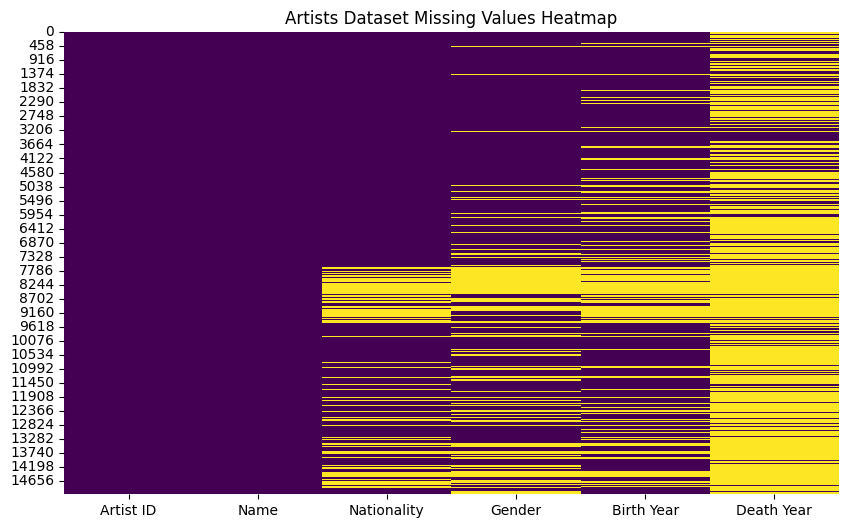

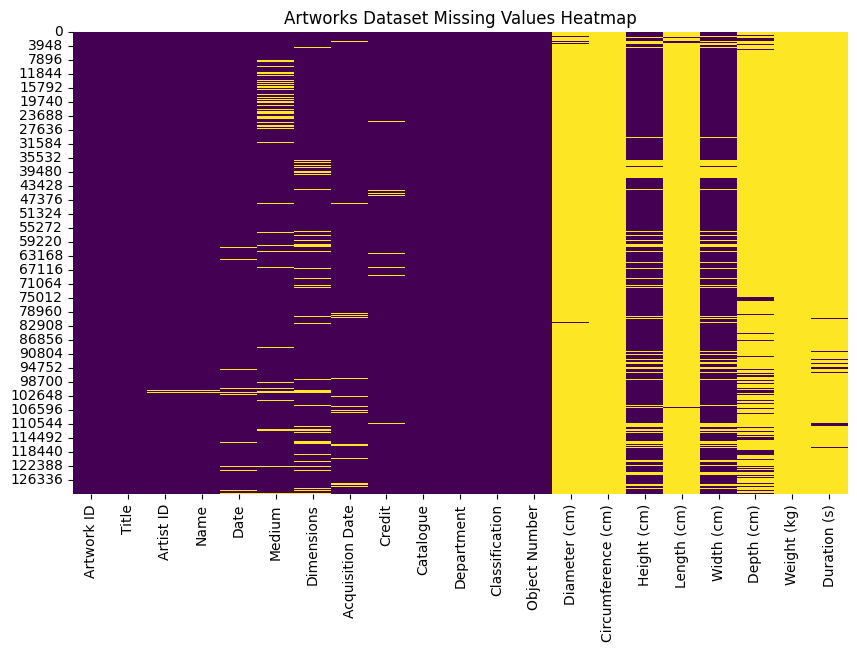

In [36]:
# Visualize missing values
def plot_missing_values(df, title):
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title(title)
    plt.show()

plot_missing_values(artists, 'Artists Dataset Missing Values Heatmap')
plot_missing_values(artworks, 'Artworks Dataset Missing Values Heatmap')

In [37]:
# Display unique values for categorical columns
print("\nUnique Values in Artists Dataset:")
for col in artists.select_dtypes(include=['object']).columns:
    print(f"{col}: {artists[col].nunique()} unique values")

print("\nUnique Values in Artworks Dataset:")
for col in artworks.select_dtypes(include=['object']).columns:
    print(f"{col}: {artworks[col].nunique()} unique values")


Unique Values in Artists Dataset:
Name: 15039 unique values
Nationality: 125 unique values
Gender: 3 unique values

Unique Values in Artworks Dataset:
Title: 94881 unique values
Artist ID: 13575 unique values
Name: 13530 unique values
Date: 9373 unique values
Medium: 19348 unique values
Dimensions: 78464 unique values
Acquisition Date: 1876 unique values
Credit: 7030 unique values
Catalogue: 2 unique values
Department: 9 unique values
Classification: 28 unique values
Object Number: 130262 unique values


# 2 - Data Cleaning

## Merging the data frames

artists and artworks can be merge since they share one column : 'Artist ID'.

In [38]:
artists['Artist ID'] = artists['Artist ID'].astype(str)
artworks['Artist ID'] = artworks['Artist ID'].astype(str)

merged_df = pd.merge(
    artworks,
    artists,
    on='Artist ID',
    how='inner',
    suffixes=('_artwork', '_artist')
)

merged_df.head()

,Artwork ID,Title,Artist ID,Name_artwork,Date,Medium,Dimensions,Acquisition Date,Credit,Catalogue,...,Length (cm),Width (cm),Depth (cm),Weight (kg),Duration (s),Name_artist,Nationality,Gender,Birth Year,Death Year
0,2,"Ferdinandsbrücke Project, Vienna, Austria, Ele...",6210,Otto Wagner,1896,Ink and cut-and-pasted painted pages on paper,"19 1/8 x 66 1/2"" (48.6 x 168.9 cm)",1996-04-09,Fractional and promised gift of Jo Carole and ...,Y,...,NaN,168.9000,NaN,NaN,NaN,Otto Wagner,Austrian,Male,1841.0,1918.0
1,3,"City of Music, National Superior Conservatory ...",7470,Christian de Portzamparc,1987,Paint and colored pencil on print,"16 x 11 3/4"" (40.6 x 29.8 cm)",1995-01-17,Gift of the architect in honor of Lily Auchinc...,Y,...,NaN,29.8451,NaN,NaN,NaN,Christian de Portzamparc,French,Male,1944.0,NaN
2,4,"Villa near Vienna Project, Outside Vienna, Aus...",7605,Emil Hoppe,1903,"Graphite, pen, color pencil, ink, and gouache ...","13 1/2 x 12 1/2"" (34.3 x 31.8 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,...,NaN,31.8000,NaN,NaN,NaN,Emil Hoppe,Austrian,Male,1876.0,1957.0
3,5,"The Manhattan Transcripts Project, New York, N...",7056,Bernard Tschumi,1980,Photographic reproduction with colored synthet...,"20 x 20"" (50.8 x 50.8 cm)",1995-01-17,Purchase and partial gift of the architect in ...,Y,...,NaN,50.8000,NaN,NaN,NaN,Bernard Tschumi,NaN,Male,1944.0,NaN
4,6,"Villa, project, outside Vienna, Austria, Exter...",7605,Emil Hoppe,1903,"Graphite, color pencil, ink, and gouache on tr...","15 1/8 x 7 1/2"" (38.4 x 19.1 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,...,NaN,19.1000,NaN,NaN,NaN,Emil Hoppe,Austrian,Male,1876.0,1957.0


In [39]:
# Check consistency for 'Name' columns
consistent_names = merged_df['Name_artwork'] == merged_df['Name_artist']
inconsistent_name_rows = merged_df[~consistent_names]

len(inconsistent_name_rows)

0

the names are consistents then we can drop one name column

In [40]:
merged_df = merged_df.drop(columns=['Name_artwork'])

merged_df.head()

,Artwork ID,Title,Artist ID,Date,Medium,Dimensions,Acquisition Date,Credit,Catalogue,Department,...,Length (cm),Width (cm),Depth (cm),Weight (kg),Duration (s),Name_artist,Nationality,Gender,Birth Year,Death Year
0,2,"Ferdinandsbrücke Project, Vienna, Austria, Ele...",6210,1896,Ink and cut-and-pasted painted pages on paper,"19 1/8 x 66 1/2"" (48.6 x 168.9 cm)",1996-04-09,Fractional and promised gift of Jo Carole and ...,Y,Architecture & Design,...,NaN,168.9000,NaN,NaN,NaN,Otto Wagner,Austrian,Male,1841.0,1918.0
1,3,"City of Music, National Superior Conservatory ...",7470,1987,Paint and colored pencil on print,"16 x 11 3/4"" (40.6 x 29.8 cm)",1995-01-17,Gift of the architect in honor of Lily Auchinc...,Y,Architecture & Design,...,NaN,29.8451,NaN,NaN,NaN,Christian de Portzamparc,French,Male,1944.0,NaN
2,4,"Villa near Vienna Project, Outside Vienna, Aus...",7605,1903,"Graphite, pen, color pencil, ink, and gouache ...","13 1/2 x 12 1/2"" (34.3 x 31.8 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,Architecture & Design,...,NaN,31.8000,NaN,NaN,NaN,Emil Hoppe,Austrian,Male,1876.0,1957.0
3,5,"The Manhattan Transcripts Project, New York, N...",7056,1980,Photographic reproduction with colored synthet...,"20 x 20"" (50.8 x 50.8 cm)",1995-01-17,Purchase and partial gift of the architect in ...,Y,Architecture & Design,...,NaN,50.8000,NaN,NaN,NaN,Bernard Tschumi,NaN,Male,1944.0,NaN
4,6,"Villa, project, outside Vienna, Austria, Exter...",7605,1903,"Graphite, color pencil, ink, and gouache on tr...","15 1/8 x 7 1/2"" (38.4 x 19.1 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,Architecture & Design,...,NaN,19.1000,NaN,NaN,NaN,Emil Hoppe,Austrian,Male,1876.0,1957.0


We can now use the merge dataframe as our only data frame

## 2a - Data Transformation/Standardization

In [41]:
!pip install missingno

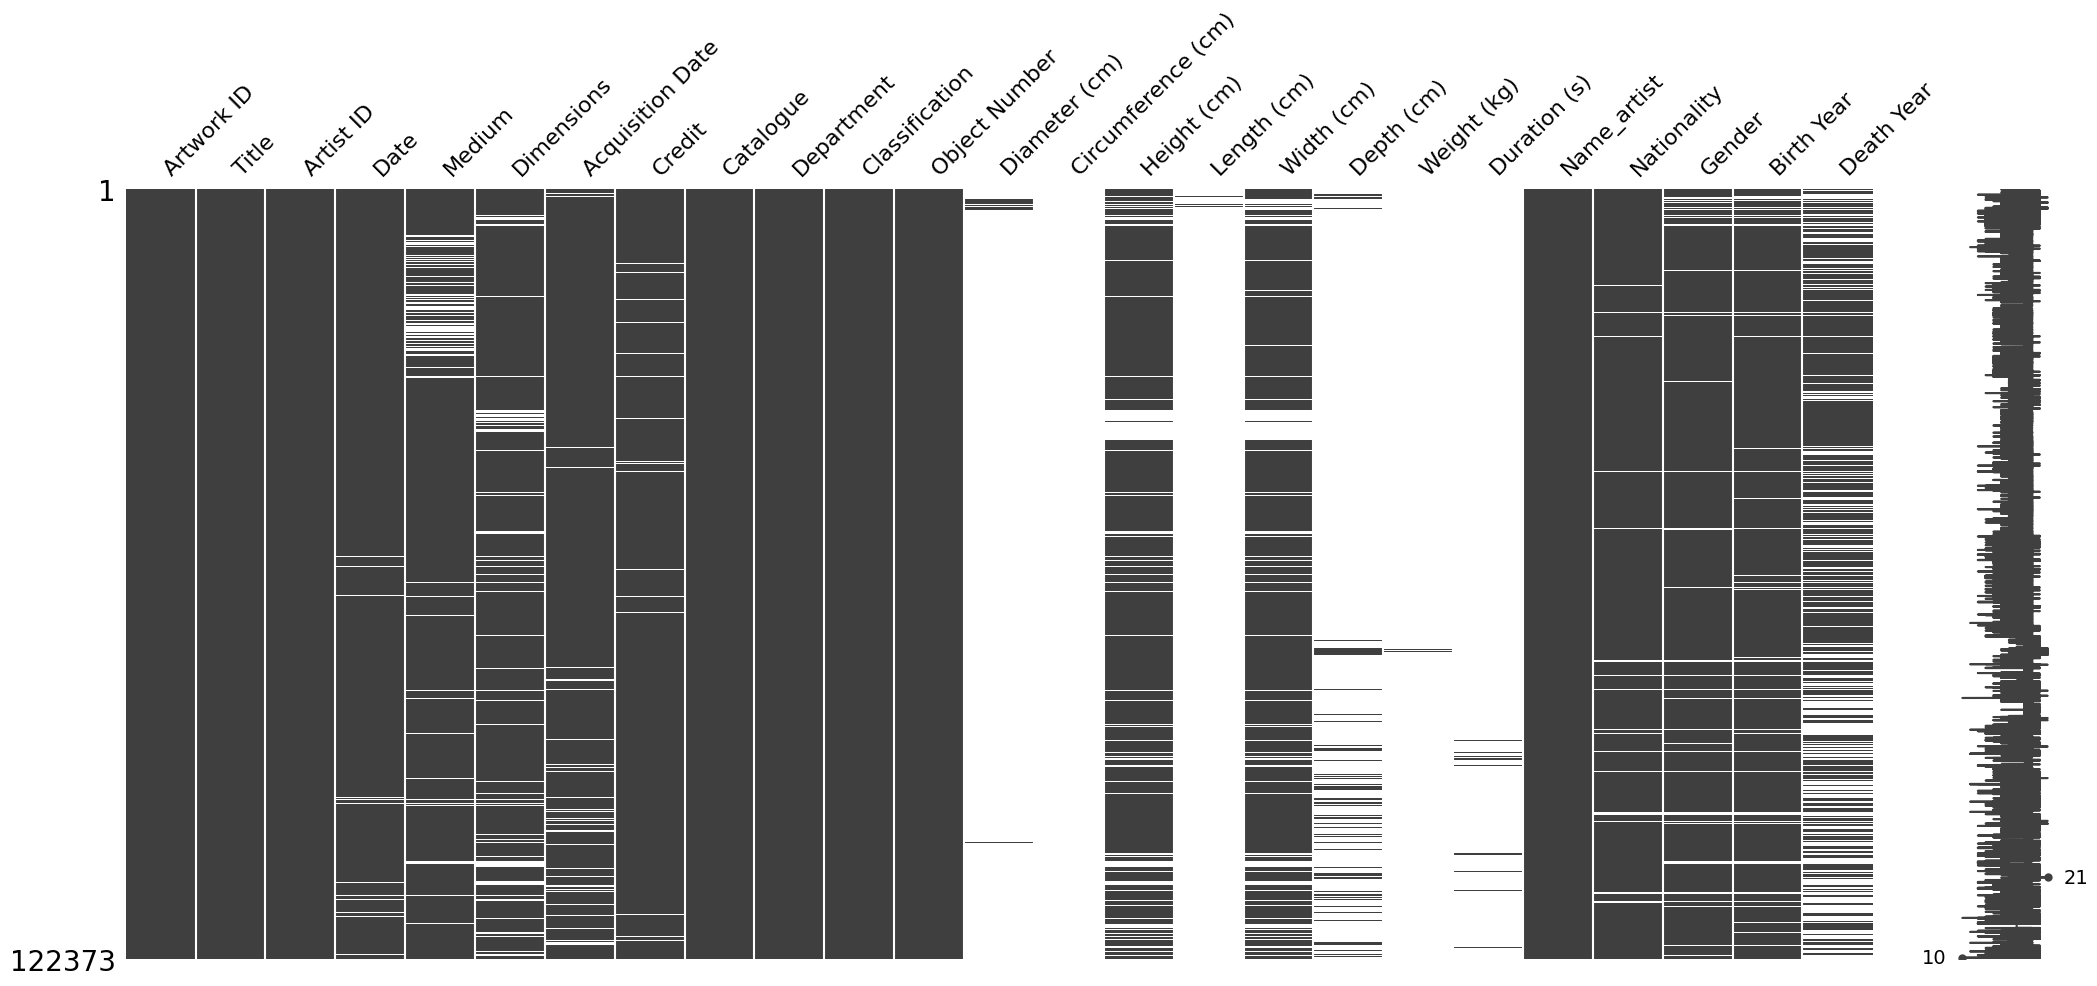

In [42]:
import missingno as msno
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(merged_df)
plt.show()


We inspected null-like values such as 'unknown', 'Unknown', '-', etc.

In [43]:

# Function to detect null-like values in merged_df
def detect_null_values(merged_df):
    null_like_values = []
    for column in merged_df.columns:
        unique_values = merged_df[column].unique()
        for value in unique_values:
            if isinstance(value, str):  # Only check string values
                if value.strip().lower() in ['na', 'n/a', 'none', 'null', 'missing', 'unknown', '?', '-', '']:
                    null_like_values.append((column, value))  # Store column and null-like value
    return null_like_values

# Detect null-like values in merged_df
null_values = detect_null_values(merged_df)

# Display the results
print("Null-like values detected in the dataset:")
for column, value in null_values:
    print(f"Column: {column}, Value: '{value}'")


Null-like values detected in the dataset:
Column: Title, Value: '-'
Column: Title, Value: 'unknown'
Column: Date, Value: 'Unknown'
Column: Date, Value: 'unknown'
Column: Medium, Value: 'Unknown'
Column: Medium, Value: '
'
Column: Dimensions, Value: '
'
Column: Name_artist, Value: 'unknown'
Column: Name_artist, Value: 'Unknown'


Manually we changed the null-like values with NaN

In [44]:

# Define null-like values
null_values = ['N/A', 'n/a', 'None', 'none', 'null', 'NULL', '-', '?', '', 'missing', 'unknown', 'Unknown']

# Replace them with NaN
merged_df.replace(null_values, np.nan, inplace=True)

# Verify the replacement
print(merged_df.isnull().sum())

Artwork ID                 0
Title                     46
Artist ID                  0
Date                    1972
Medium                 11233
Dimensions             10348
Acquisition Date        5130
Credit                  2675
Catalogue                  0
Department                 0
Classification             0
Object Number              0
Diameter (cm)         121098
Circumference (cm)    122364
Height (cm)            16849
Length (cm)           121704
Width (cm)             17659
Depth (cm)            113092
Weight (kg)           122082
Duration (s)          119807
Name_artist               15
Nationality             3310
Gender                  6196
Birth Year              7155
Death Year             45211
dtype: int64


Unique Categories and Counts


In [45]:
# Columns to analyze
categorical_columns = ['Gender', 'Nationality', 'Catalogue', 'Department']

# Analyze each column
for column in categorical_columns:
    print(f"\nColumn: {column}")
    print("Unique values and their counts:")
    print(merged_df[column].value_counts(dropna=False))  # Includes NaN in counts


Column: Gender
Unique values and their counts:
Gender
Male      99979
Female    16193
NaN        6196
male          5
Name: count, dtype: int64

Column: Nationality
Unique values and their counts:
Nationality
American       54545
French         22303
German          8987
British         5500
NaN             3310
               ...  
Tanzanian          1
Guyanese           1
Ivorian            1
Azerbaijani        1
Paraguayan         1
Name: count, Length: 122, dtype: int64

Column: Catalogue
Unique values and their counts:
Catalogue
Y    66951
N    55422
Name: count, dtype: int64

Column: Department
Unique values and their counts:
Department
Prints & Illustrated Books               57748
Photography                              27810
Architecture & Design                    16009
Drawings                                 10865
Painting & Sculpture                      3790
Film                                      2407
Media and Performance Art                 2233
Fluxus Collection  

We analyzed and found we only have a problem with genders, as five of them were additionally written as 'male,' which holding same meaning with 'Male'. We also analyzed the country names for potential misspellings, as these can be difficult to write correctly.

'male' to 'Male'

In [46]:
# Replace "male" with "Male" in the Gender column
merged_df['Gender'] = merged_df['Gender'].replace('male', 'Male')

# Verify the change
print(merged_df['Gender'].value_counts())

Gender
Male      99984
Female    16193
Name: count, dtype: int64


Nationality Corrections

In [47]:
# Step 1: Extract unique nationalities
unique_nationalities = merged_df['Nationality'].str.strip().str.title().unique()
print("Unique Nationalities:\n", unique_nationalities)

Unique Nationalities:
 ['Austrian' 'French' nan 'American' 'German' 'Swedish' 'British'
 'Japanese' 'Italian' 'Argentine' 'Swiss' 'Brazilian' 'Luxembourgish'
 'Spanish' 'Dutch' 'Russian' 'Iranian' 'Finnish' 'Nationality Unknown'
 'Danish' 'Belgian' 'Czech' 'Moroccan' 'Colombian' 'Australian' 'Chinese'
 'Mexican' 'Yugoslav' 'Hungarian' 'Canadian' 'Polish' 'Slovenian'
 'Chilean' 'Latvian' 'Various' 'Greek' 'Israeli' 'Icelandic'
 'Czechoslovakian' 'Croatian' 'Norwegian' 'Cuban' 'Romanian' 'Venezuelan'
 'Uruguayan' 'Thai' 'Algerian' 'Guatemalan' 'Indian' 'Ukrainian' 'Irish'
 'Costa Rican' 'Korean' 'Ethiopian' 'Kuwaiti' 'Haitian' 'Scottish'
 'South African' 'Zimbabwean' 'Portuguese' 'Panamanian' 'Ecuadorian'
 'Peruvian' 'Congolese' 'Malian' 'Turkish' 'Cambodian' 'Bosnian'
 'Canadian Inuit' 'Slovak' 'Estonian' 'Pakistani' 'Bulgarian' 'Bolivian'
 'Taiwanese' 'Paraguayan' 'Nicaraguan' 'Tunisian' 'Sudanese' 'Tanzanian'
 'Guyanese' 'Senegalese' 'Bahamian' 'Lebanese' 'Kenyan' 'Nigerian'
 'Georgia

In [48]:
import numpy as np

def preprocess_nationality(nationality):
    # Handle non-string values and clean whitespace
    if pd.isnull(nationality):  # Check for missing values
        return np.nan
    if not isinstance(nationality, str):  # Ensure it's a string
        return np.nan
    nationality = nationality.strip().title()  # Remove extra spaces and title-case

    # Replace specific invalid cases with np.nan
    if nationality in ["Nationality Unknown", "Nan"]:
        return np.nan
    return nationality

# Apply the function to the 'Nationality' column
merged_df['Nationality'] = merged_df['Nationality'].apply(preprocess_nationality)

# Verify unique values after processing
print("Unique Nationalities:\n", merged_df['Nationality'].unique())


Unique Nationalities:
 ['Austrian' 'French' nan 'American' 'German' 'Swedish' 'British'
 'Japanese' 'Italian' 'Argentine' 'Swiss' 'Brazilian' 'Luxembourgish'
 'Spanish' 'Dutch' 'Russian' 'Iranian' 'Finnish' 'Danish' 'Belgian'
 'Czech' 'Moroccan' 'Colombian' 'Australian' 'Chinese' 'Mexican'
 'Yugoslav' 'Hungarian' 'Canadian' 'Polish' 'Slovenian' 'Chilean'
 'Latvian' 'Various' 'Greek' 'Israeli' 'Icelandic' 'Czechoslovakian'
 'Croatian' 'Norwegian' 'Cuban' 'Romanian' 'Venezuelan' 'Uruguayan' 'Thai'
 'Algerian' 'Guatemalan' 'Indian' 'Ukrainian' 'Irish' 'Costa Rican'
 'Korean' 'Ethiopian' 'Kuwaiti' 'Haitian' 'Scottish' 'South African'
 'Zimbabwean' 'Portuguese' 'Panamanian' 'Ecuadorian' 'Peruvian'
 'Congolese' 'Malian' 'Turkish' 'Cambodian' 'Bosnian' 'Canadian Inuit'
 'Slovak' 'Estonian' 'Pakistani' 'Bulgarian' 'Bolivian' 'Taiwanese'
 'Paraguayan' 'Nicaraguan' 'Tunisian' 'Sudanese' 'Tanzanian' 'Guyanese'
 'Senegalese' 'Bahamian' 'Lebanese' 'Kenyan' 'Nigerian' 'Georgian'
 'Egyptian' 'Albania

We inspected the Birth Year and Death Year are float.




In [49]:
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122373 entries, 0 to 122372
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Artwork ID          122373 non-null  int64  
 1   Title               122327 non-null  object 
 2   Artist ID           122373 non-null  object 
 3   Date                120401 non-null  object 
 4   Medium              111140 non-null  object 
 5   Dimensions          112025 non-null  object 
 6   Acquisition Date    117243 non-null  object 
 7   Credit              119698 non-null  object 
 8   Catalogue           122373 non-null  object 
 9   Department          122373 non-null  object 
 10  Classification      122373 non-null  object 
 11  Object Number       122373 non-null  object 
 12  Diameter (cm)       1275 non-null    float64
 13  Circumference (cm)  9 non-null       float64
 14  Height (cm)         105524 non-null  float64
 15  Length (cm)         669 non-null  

We transformed Birth Year and Death Year from float64 to int64

In [50]:
# Ensure the Birth Year and Death Year columns are properly cleaned before conversion
merged_df['Birth Year'] = (
    pd.to_numeric(merged_df['Birth Year'], errors='coerce')  # Coerce invalid entries to NaN
    .fillna(pd.NA)  # Ensure missing values are recognized as pandas NA
    .astype('Int64')  # Convert to nullable Int64 type
)

merged_df['Death Year'] = (
    pd.to_numeric(merged_df['Death Year'], errors='coerce')
    .fillna(pd.NA)
    .astype('Int64')
)

# Check the changes
print(merged_df[['Birth Year', 'Death Year']].info())
print(merged_df[['Birth Year', 'Death Year']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122373 entries, 0 to 122372
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Birth Year  115218 non-null  Int64
 1   Death Year  77162 non-null   Int64
dtypes: Int64(2)
memory usage: 2.1 MB
None
   Birth Year  Death Year
0        1841        1918
1        1944        <NA>
2        1876        1957
3        1944        <NA>
4        1876        1957


In [51]:
print(merged_df['Birth Year'].unique())
print(merged_df['Death Year'].unique())

<IntegerArray>
[1841, 1944, 1876, 1901, 1878, 1869, 1933, 1949, 1934, 1886,
 ...
 2005, 1789, 1782, 1986, 2004, 1989, 2012, 2003, 2010, 2002]
Length: 216, dtype: Int64
<IntegerArray>
[1918, <NA>, 1957, 1974, 1969, 1961, 1936, 2010, 1991, 2015,
 ...
 1880, 1864, 1865, 1911, 1887, 1884, 1873, 1851, 1859, 1852]
Length: 164, dtype: Int64


Case Consistency

This step involves checking the 'Title' and 'Medium' columns for unique values to identify inconsistencies. We display the count of unique entries and preview a sample to understand the data's current state before standardizing case formats.

In [52]:
# Display unique values for 'Title' and 'Medium'
print("Unique values in 'Title':", merged_df['Title'].nunique())
print("Unique values in 'Medium':", merged_df['Medium'].nunique())

# Preview a sample of unique values
print("\nSample unique 'Title' values:")
print(merged_df['Title'].dropna().unique()[:10])  # Display first 10 unique values
print("\nSample unique 'Medium' values:")
print(merged_df['Medium'].dropna().unique()[:10])


Unique values in 'Title': 89481
Unique values in 'Medium': 17941

Sample unique 'Title' values:
['Ferdinandsbrücke Project, Vienna, Austria, Elevation, preliminary version'
 'City of Music, National Superior Conservatory of Music and Dance, Paris, France, View from interior courtyard'
 'Villa near Vienna Project, Outside Vienna, Austria, Elevation'
 'The Manhattan Transcripts Project, New York, New York, Introductory panel to Episode 1: The Park'
 'Villa, project, outside Vienna, Austria, Exterior perspective'
 'The Manhattan Transcripts Project, New York, New York, Episode 1: The Park'
 'The Manhattan Transcripts Project, New York, New York , Episode 1: The Park'
 'Memorial to the Six Million Jewish Martyrs, project, New York City, New York, Perspective of central pier'
 'The Manhattan Transcripts Project, New York, New York, Introductory panel to Episode 2: The Street (Border Crossing)'
 'Royal Hunting Tent, project, Exterior perspective']

Sample unique 'Medium' values:
['Ink and cu

Cleaning 'Title' and 'Medium' Columns

This step focuses on cleaning and standardizing the 'Title' and 'Medium' columns. We remove extra spaces and ensure consistency by replacing multiple spaces with a single one. Additionally, the 'Medium' column is formatted to title case to maintain uniformity.



In [53]:
# Clean 'Title' and 'Medium' columns
merged_df['Title'] = (
    merged_df['Title']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

merged_df['Medium'] = (
    merged_df['Medium']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)


Standardizing Date Formats

This step involves checking the current formats of the 'Date' and 'Acquisition Date' columns. We then convert 'Acquisition Date' to a standard 'YYYY-MM-DD' format for consistency and verify the conversion with a preview of the data.

In [54]:
# Check current format of 'Date' and 'Acquisition Date'
print("Date of artwork")
print(merged_df['Date'].head())
print("\nDate of acquisition")
print(merged_df['Acquisition Date'].head())

# Convert to standard format
merged_df['Acquisition Date'] = pd.to_datetime(merged_df['Acquisition Date'], errors='coerce').dt.strftime('%Y-%m-%d')

# Verify conversion
print(merged_df[['Date', 'Acquisition Date']].head())



Date of artwork
0    1896
1    1987
2    1903
3    1980
4    1903
Name: Date, dtype: object

Date of acquisition
0    1996-04-09
1    1995-01-17
2    1997-01-15
3    1995-01-17
4    1997-01-15
Name: Acquisition Date, dtype: object
   Date Acquisition Date
0  1896       1996-04-09
1  1987       1995-01-17
2  1903       1997-01-15
3  1980       1995-01-17
4  1903       1997-01-15


Detecting and Correcting Typos in 'Medium'

This step uses fuzzy matching to identify and correct potential typos in the 'Medium' column. We compare unique values with a similarity threshold to suggest corrections, which are then applied to ensure consistency in the dataset.



In [55]:
!pip install fuzzywuzzy
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.7/162.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.7 MB/s eta 0:00:00


In [56]:
from rapidfuzz import process, fuzz

# Get unique values in 'Medium'
unique_mediums = merged_df['Medium'].dropna().unique()

# Define a threshold for similarity
similarity_threshold = 95

# Create an empty dictionary to store corrections
potential_typos = {}

# Compare each unique value against the remaining values
for i, medium in enumerate(unique_mediums):
    matches = process.extract(medium, unique_mediums[i+1:], limit=10, scorer=fuzz.ratio)  # Only compare with next values
    for match in matches:
        if match[1] >= similarity_threshold and match[0] != medium:
            potential_typos[medium] = match[0]

# Print potential typos
print("Potential typos and suggested corrections:")
for typo, correction in potential_typos.items():
    print(f"{typo} -> {correction}")

# Apply corrections to the dataframe
for typo, correction in potential_typos.items():
    merged_df['Medium'] = merged_df['Medium'].replace(typo, correction)



Potential typos and suggested corrections:
Graphite, Pen, Color Pencil, Ink, And Gouache On Tracing Paper -> Graphite, Color Pencil, Ink, And Gouache On Tracing Paper
Gelatin Silver Photograph -> Gelatin Silver Photographs
Pen, Ink, And Gouache On Paper -> Pencil, Ink, And Gouache On Paper
Ink On Paper Mounted On Board -> Ink On Paper, Mounted On Board
Graphite And Color Pencil On Tracing Paper -> Graphite And Colored Pencil On Tracing Paper
Colored Pencil On Tracing Paper -> Color Pencil On Tracing Paper
Graphite And Colored Pencil On Paper -> Graphite And Color Pencil On Paper
Felt-Tipped Pen On Tracing Paper -> Felt-Tippped Pen On Tracing Paper
Lithograph -> Lithograph,
Colored Pencil On Print -> Color Pencil On Print
Color Pencil On Board -> Colored Pencil On Board
Pencil And Color Pencil On Tracing Paper -> Penci And Colored Pencil On Tracing Paper
Color Pencil On Paper -> Colored Pencil On Paper
Pencil On Tracing Paper -> Pencil On Tracing Paper.
See Individual Records. -> See In

In [57]:
for typo, correction in potential_typos.items():
    print(f"{typo} -> {correction} (Score: {fuzz.ratio(typo, correction)})")


Graphite, Pen, Color Pencil, Ink, And Gouache On Tracing Paper -> Graphite, Color Pencil, Ink, And Gouache On Tracing Paper (Score: 95.7983193277311)
Gelatin Silver Photograph -> Gelatin Silver Photographs (Score: 98.0392156862745)
Pen, Ink, And Gouache On Paper -> Pencil, Ink, And Gouache On Paper (Score: 95.23809523809523)
Ink On Paper Mounted On Board -> Ink On Paper, Mounted On Board (Score: 98.30508474576271)
Graphite And Color Pencil On Tracing Paper -> Graphite And Colored Pencil On Tracing Paper (Score: 97.67441860465115)
Colored Pencil On Tracing Paper -> Color Pencil On Tracing Paper (Score: 96.66666666666667)
Graphite And Colored Pencil On Paper -> Graphite And Color Pencil On Paper (Score: 97.14285714285714)
Felt-Tipped Pen On Tracing Paper -> Felt-Tippped Pen On Tracing Paper (Score: 98.46153846153847)
Lithograph -> Lithograph, (Score: 95.23809523809523)
Colored Pencil On Print -> Color Pencil On Print (Score: 95.45454545454545)
Color Pencil On Board -> Colored Pencil On B

## 2b - Error Detection and Correction

### Missing Values

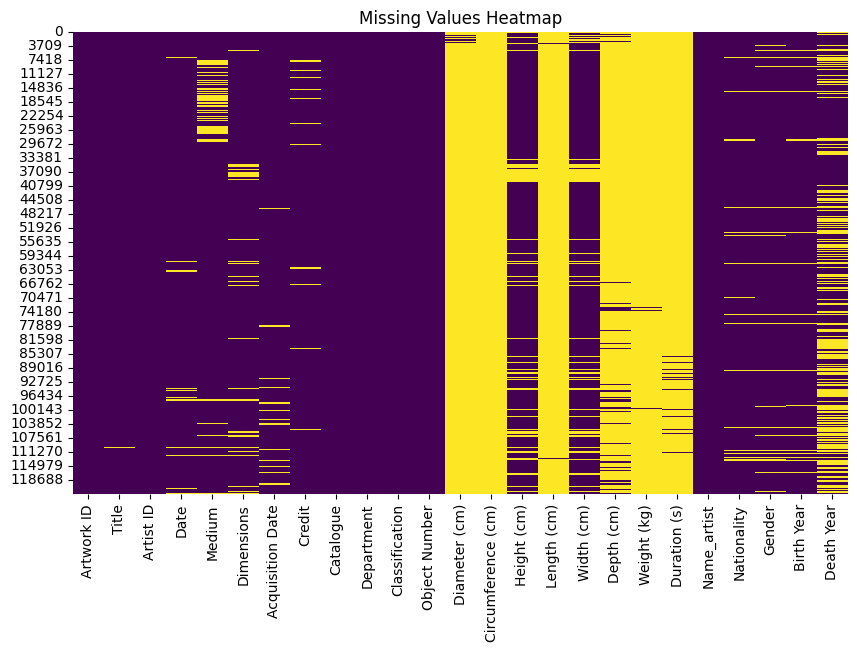

In [58]:
plot_missing_values(merged_df, 'Missing Values Heatmap')

#### Drop some columns

We observe that there are almost no values for: 'Diameter (cm)', 'Length (cm)', 'Depth (cm)', 'Weight (kg)', 'Duration (s)', and 'Circumference (cm)'.
Hence, we decide to drop those columns.

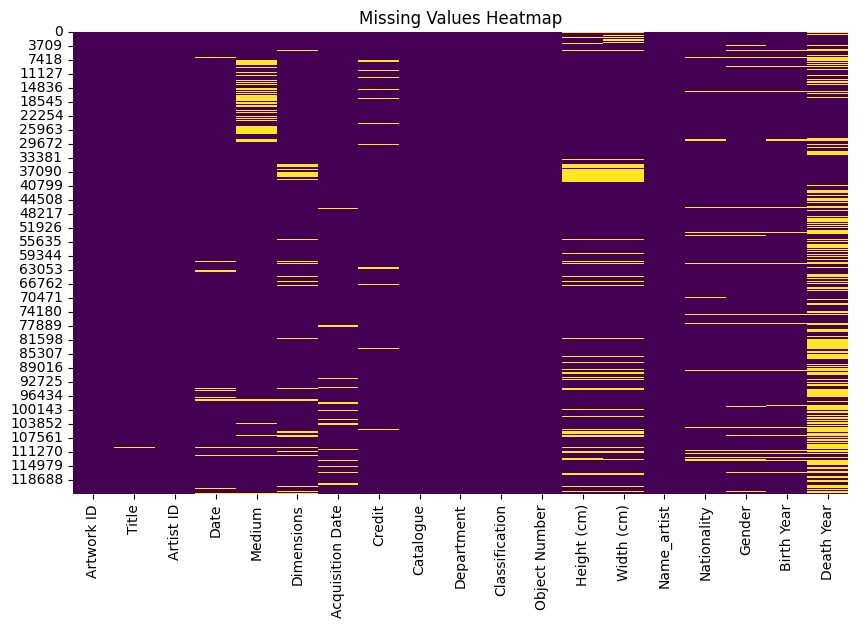

In [59]:
columns_to_drop = ['Diameter (cm)', 'Length (cm)', 'Depth (cm)', 'Weight (kg)', 'Duration (s)', 'Circumference (cm)']
merged_df.drop(columns=columns_to_drop, inplace=True)
plot_missing_values(merged_df, 'Missing Values Heatmap')

#### 'Death Year' columns

In [60]:
merged_df['Death Year']

,Death Year
0,1918
1,<NA>
2,1957
3,<NA>
4,1957
...,...
122368,1998
122369,2006
122370,2006
122371,<NA>


The 'Death Year' contains NaN values we should replace them to have all the values as int64. For that we decide to replace the Death Year of artists that are not dead by: 9999

In [61]:
merged_df['Death Year'] = merged_df['Death Year'].fillna(9999)
merged_df['Death Year']

,Death Year
0,1918
1,9999
2,1957
3,9999
4,1957
...,...
122368,1998
122369,2006
122370,2006
122371,9999


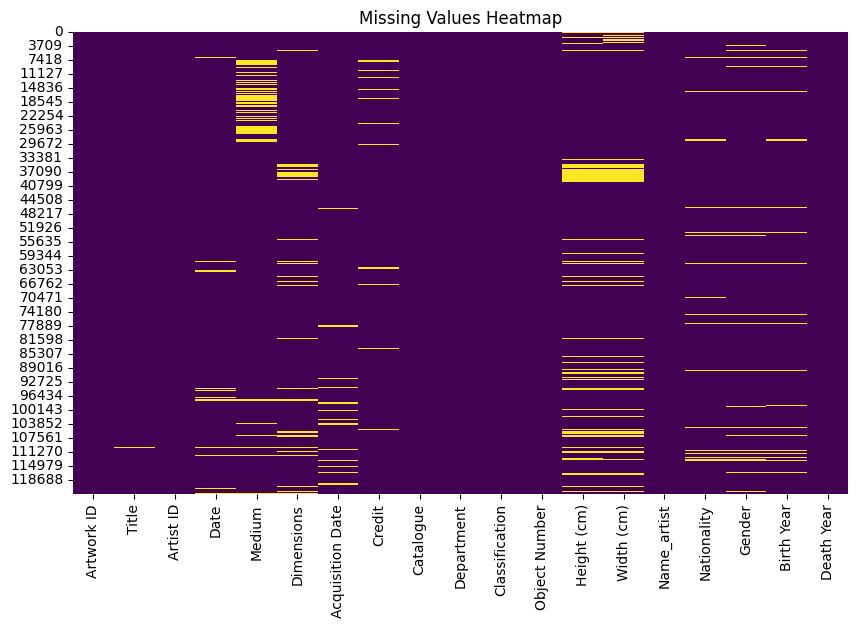

In [62]:
plot_missing_values(merged_df, 'Missing Values Heatmap')

#### 'Title', 'Medium', 'Credit' columns
we simply replace missing values, their is not any possibility to predict them or to replace them in any other ways

In [63]:
merged_df['Title'].fillna("Untitled", inplace=True)
merged_df['Medium'].fillna("Unknown Medium", inplace=True)
merged_df['Credit'].fillna("Unknown Credit", inplace=True)

<ipython-input-63-2feac4aca7f4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['Title'].fillna("Untitled", inplace=True)
<ipython-input-63-2feac4aca7f4>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

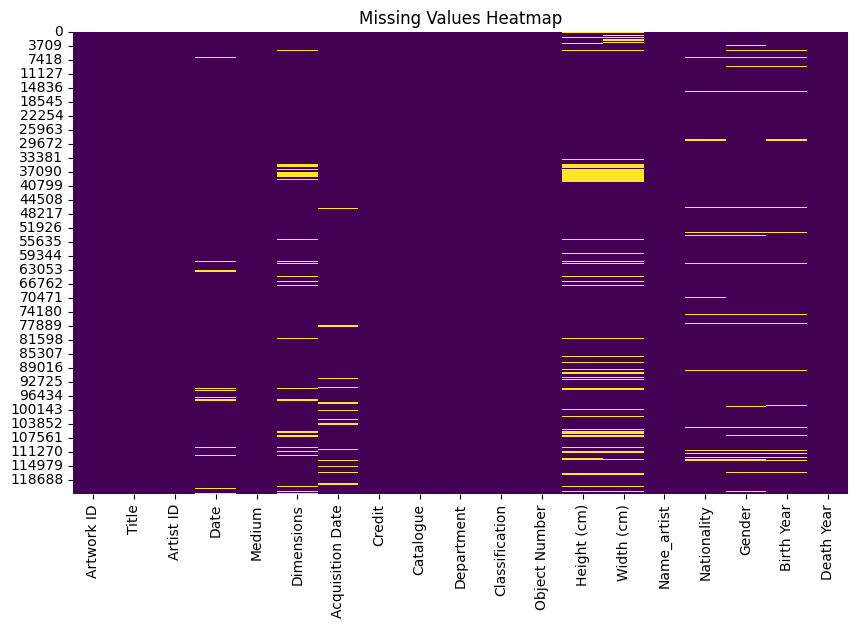

In [64]:
plot_missing_values(merged_df, 'Missing Values Heatmap')

#### 'Gender', 'Nationality'
we simply fill the missing values by the most commun value

In [65]:
most_common_gender = merged_df['Gender'].mode()[0]
most_common_nationality = merged_df['Nationality'].mode()[0]

print("Most common gender:     ", most_common_gender)
print("Most common Nationality:", most_common_nationality)

Most common gender:      Male
Most common Nationality: American


<ipython-input-66-87cb17c3ab8f>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['Gender'].fillna(most_common_gender, inplace=True)
<ipython-input-66-87cb17c3ab8f>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

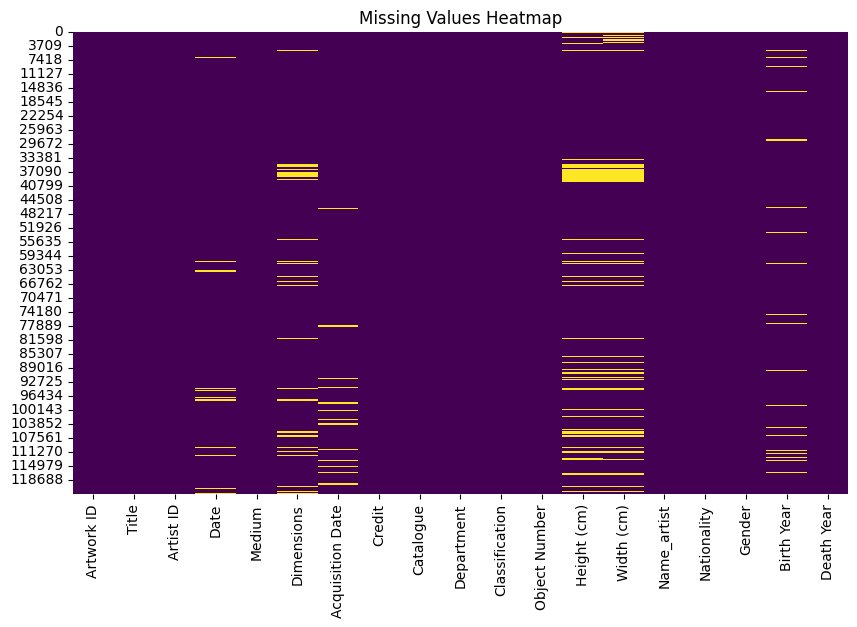

In [66]:
merged_df['Gender'].fillna(most_common_gender, inplace=True)
merged_df['Nationality'].fillna(most_common_nationality, inplace=True)

plot_missing_values(merged_df, 'Missing Values Heatmap')

#### 'Height', 'Width', 'Birth Year' columns

For this ones we will predict with the k-nearest neighbors

In [67]:
missing_columns = ['Height (cm)', 'Width (cm)', 'Birth Year']

numerical_columns = ['Death Year', 'Birth Year', 'Width (cm)', 'Height (cm)']

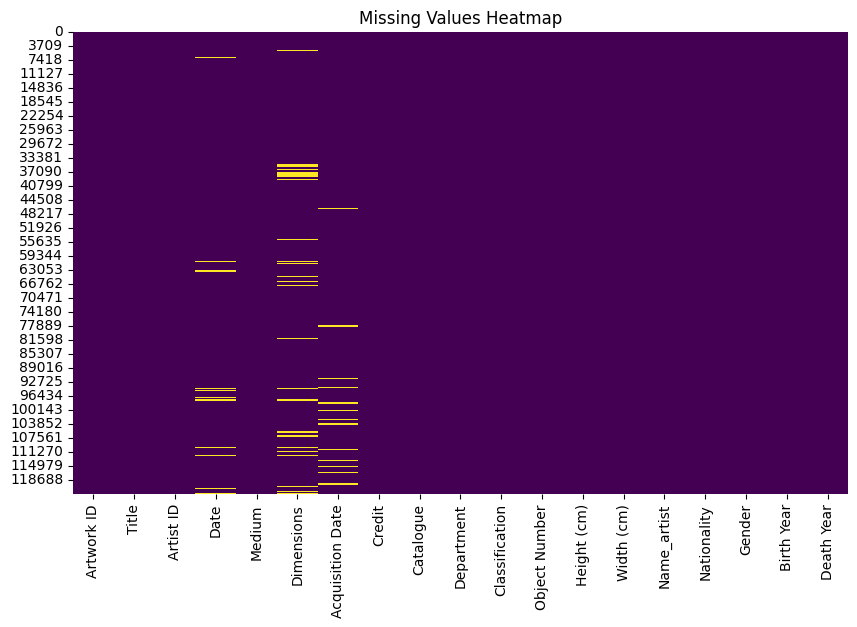

In [68]:
from sklearn.impute import KNNImputer

df = merged_df[numerical_columns].copy()

IMPUTER = KNNImputer(n_neighbors=5)

df_knn = pd.DataFrame(IMPUTER.fit_transform(df))
df_knn.columns = df.columns
for col in missing_columns:
    merged_df[col] = df_knn[col]
plot_missing_values(merged_df, 'Missing Values Heatmap')

We can check that we did not compute any Birth Year that are greater than death year

In [69]:
len(merged_df[merged_df['Birth Year'] - merged_df['Death Year'] >= 0])

0

#### 'Dimensions' column
Use height and width to compute the dimension column (at least partially)

In [70]:
merged_df[['Dimensions','Height (cm)', 'Width (cm)']]

,Dimensions,Height (cm),Width (cm)
0,"19 1/8 x 66 1/2"" (48.6 x 168.9 cm)",48.6000,168.9000
1,"16 x 11 3/4"" (40.6 x 29.8 cm)",40.6401,29.8451
2,"13 1/2 x 12 1/2"" (34.3 x 31.8 cm)",34.3000,31.8000
3,"20 x 20"" (50.8 x 50.8 cm)",50.8000,50.8000
4,"15 1/8 x 7 1/2"" (38.4 x 19.1 cm)",38.4000,19.1000
...,...,...,...
122368,NaN,0.0000,0.0000
122369,NaN,0.0000,0.0000
122370,NaN,0.0000,0.0000
122371,NaN,0.0000,0.0000


In [71]:
def construct_dimensions(row):
    if pd.isna(row['Dimensions']):
        return f"({row['Height (cm)']:.1f} x {row['Width (cm)']:.1f} cm)"
    return row['Dimensions']

merged_df['Dimensions'] = merged_df.apply(construct_dimensions, axis=1)

merged_df[['Dimensions','Height (cm)', 'Width (cm)']]

,Dimensions,Height (cm),Width (cm)
0,"19 1/8 x 66 1/2"" (48.6 x 168.9 cm)",48.6000,168.9000
1,"16 x 11 3/4"" (40.6 x 29.8 cm)",40.6401,29.8451
2,"13 1/2 x 12 1/2"" (34.3 x 31.8 cm)",34.3000,31.8000
3,"20 x 20"" (50.8 x 50.8 cm)",50.8000,50.8000
4,"15 1/8 x 7 1/2"" (38.4 x 19.1 cm)",38.4000,19.1000
...,...,...,...
122368,(0.0 x 0.0 cm),0.0000,0.0000
122369,(0.0 x 0.0 cm),0.0000,0.0000
122370,(0.0 x 0.0 cm),0.0000,0.0000
122371,(0.0 x 0.0 cm),0.0000,0.0000


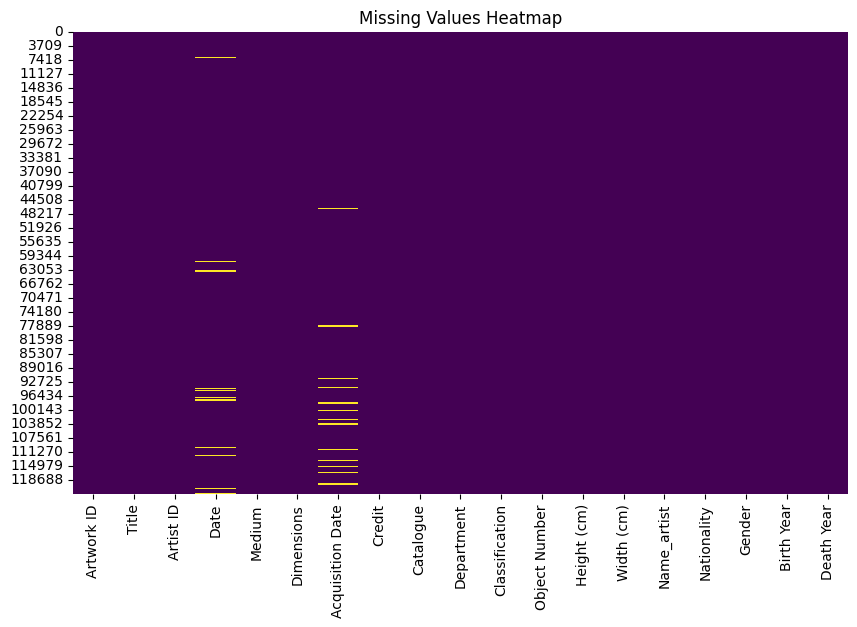

In [72]:
plot_missing_values(merged_df, 'Missing Values Heatmap')

#### 'Acquisition Date' and 'Date' columns
fill missing dates by the median

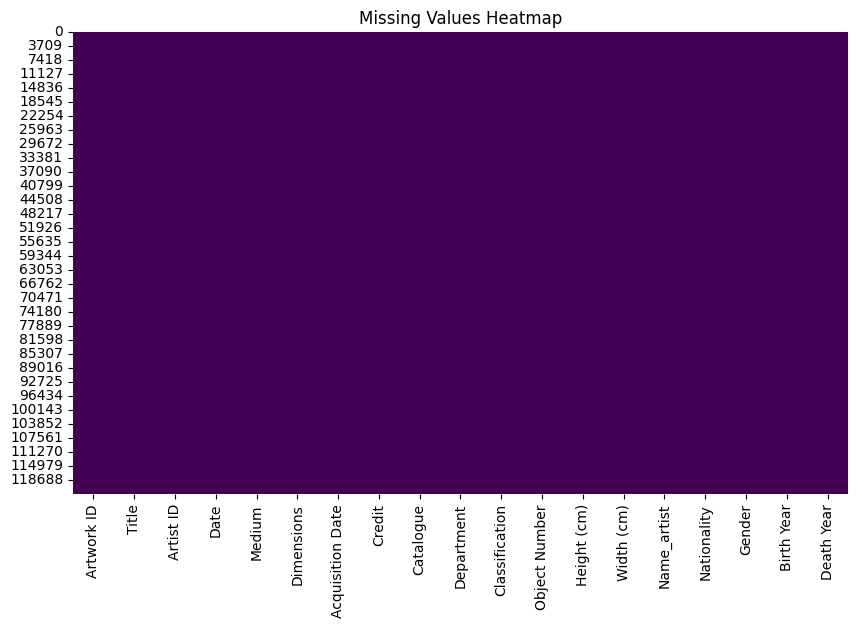

In [73]:
# need to convert this one into a date format
merged_df['Acquisition Date'] = pd.to_datetime(merged_df['Acquisition Date'], errors='coerce')
merged_df['Date'] = pd.to_datetime(merged_df['Date'], errors='coerce')

acquisition_median = merged_df['Acquisition Date'].median()
date_median = merged_df['Date'].median()

merged_df['Acquisition Date'] = merged_df['Acquisition Date'].fillna(acquisition_median)
merged_df['Date'] = merged_df['Date'].fillna(date_median)

plot_missing_values(merged_df, 'Missing Values Heatmap')

we have no more missing values

### Outliers
Potential outliers could be found in the size of the artwork, i.e., the height the width. All the columns can't really possess outliers. To detect the outliers we will the most advance techniques seen in class: DBSCAN

In [74]:
from sklearn.cluster import DBSCAN
import numpy as np

<ipython-input-75-32fccb31412d>:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data['Height (cm)'], data['Width (cm)'], cmap='Paired')


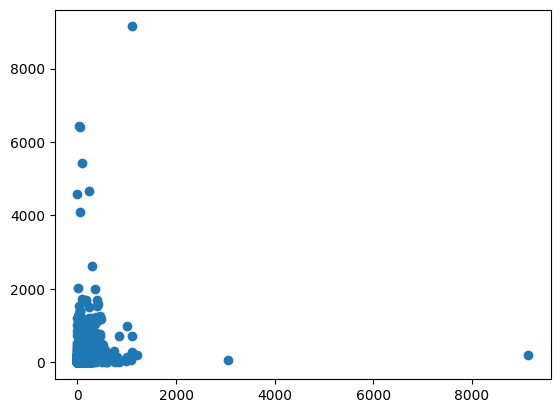

In [75]:
data = merged_df[['Height (cm)', 'Width (cm)']]
plt.scatter(data['Height (cm)'], data['Width (cm)'], cmap='Paired')

We need to transform the data in order to apply the DBSCAN algorithm. For that we will use the log1.

<ipython-input-76-b10ca6da4368>:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_transformed['Height (cm)'], data_transformed['Width (cm)'], cmap='Paired')


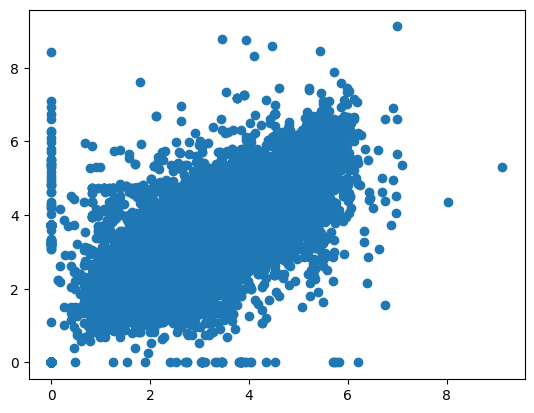

In [76]:
data_transformed = np.log1p(data)
plt.scatter(data_transformed['Height (cm)'], data_transformed['Width (cm)'], cmap='Paired')

In [77]:
dbscan = DBSCAN(min_samples = 2, eps = 0.1)
clusters = dbscan.fit_predict(data_transformed)
clusters

array([0, 0, 0, ..., 3, 3, 3])

In [78]:
#Founded outliers belong to the cluster -1
clusters[clusters > -1] = 0
list(clusters).count(-1)

217

<ipython-input-79-70495d5b6479>:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data_transformed['Height (cm)'], data_transformed['Width (cm)'],c=colormap[clusters], cmap='Paired')


Text(0.5, 1.0, 'DBSCAN')

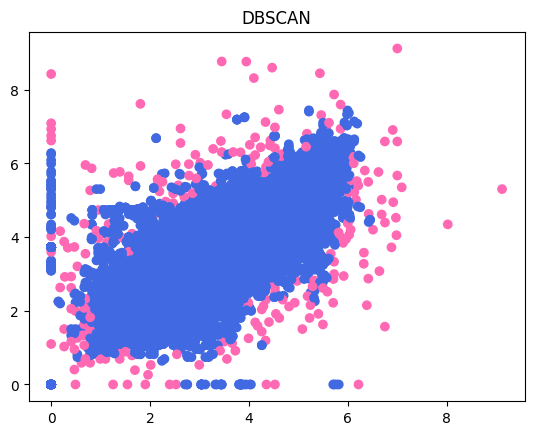

In [79]:
colormap = np.array(['royalblue', 'hotpink'])

plt.scatter(data_transformed['Height (cm)'], data_transformed['Width (cm)'],c=colormap[clusters], cmap='Paired')
plt.title("DBSCAN")

<ipython-input-80-559318836eba>:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data['Height (cm)'], data['Width (cm)'],c=colormap[clusters], cmap='Paired')


Text(0.5, 1.0, 'DBSCAN')

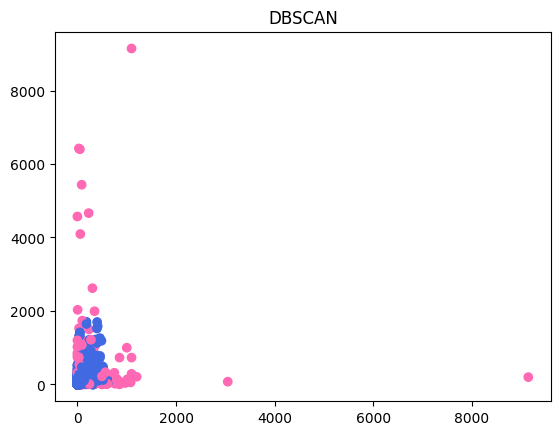

In [80]:
colormap = np.array(['royalblue', 'hotpink'])

plt.scatter(data['Height (cm)'], data['Width (cm)'],c=colormap[clusters], cmap='Paired')
plt.title("DBSCAN")

We can see that we are able to find well the outliers. In our case we will not remove them since it is a database made for storage, not predictions, but if we needed to make predictions we could remove them.

## 2c - Data Deduplication

###Exact Matching

We checked the dataset for any duplication and initially found no significant duplicates. However, upon more detailed inspection, we realized that the "Object Number" column was causing false duplications as it did not hold meaningful data for this purpose. Therefore, we decided to exclude the "Object Number" column. Along with it, we also excluded the "Artwork ID" column, as it was simply an enumeration. After these adjustments, the dataset was cleaned, ensuring no exact duplicates remained

In [95]:
merged_df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
122368,False
122369,False
122370,False
122371,False


In [82]:
merged_df.duplicated().any()

False

In [91]:
merged_df.columns = merged_df.columns.str.strip()

In [93]:
print(merged_df.columns)


Index(['Artwork ID', 'Title', 'Artist ID', 'Date', 'Medium', 'Dimensions',
       'Acquisition Date', 'Credit', 'Catalogue', 'Department',
       'Classification', 'Object Number', 'Height (cm)', 'Width (cm)',
       'Name_artist', 'Nationality', 'Gender', 'Birth Year', 'Death Year'],
      dtype='object')


In [101]:
# Check rows 5 to 9 manually
suspected_rows = merged_df.iloc[5:10]
print(suspected_rows)


   Artwork ID                                              Title Artist ID  \
5           7  The Manhattan Transcripts Project, New York, N...      7056   
6           8  The Manhattan Transcripts Project, New York, N...      7056   
7           9  The Manhattan Transcripts Project, New York, N...      7056   
8          10  The Manhattan Transcripts Project, New York, N...      7056   
9          11  The Manhattan Transcripts Project, New York, N...      7056   

        Date                      Medium                       Dimensions  \
5 1966-01-01  Gelatin Silver Photographs        14 x 18" (35.6 x 45.7 cm)   
6 1966-01-01  Gelatin Silver Photographs  Each: 14 x 18" (35.6 x 45.7 cm)   
7 1966-01-01  Gelatin Silver Photographs        14 x 18" (35.6 x 45.7 cm)   
8 1966-01-01  Gelatin Silver Photographs        14 x 18" (35.6 x 45.7 cm)   
9 1966-01-01  Gelatin Silver Photographs        14 x 18" (35.6 x 45.7 cm)   

  Acquisition Date                                             Credi

In [102]:
# Compare rows 5 and 6 to see any differences
row_5 = merged_df.iloc[5]
row_6 = merged_df.iloc[6]

# Check the differences between row 5 and row 6
differences = row_5 != row_6
print("Differences between row 5 and row 6:")
print(differences)


Differences between row 5 and row 6:
Artwork ID           True
Title               False
Artist ID           False
Date                False
Medium              False
Dimensions           True
Acquisition Date    False
Credit              False
Catalogue           False
Department          False
Classification      False
Object Number        True
Height (cm)         False
Width (cm)          False
Name_artist         False
Nationality         False
Gender              False
Birth Year          False
Death Year          False
dtype: bool


In [94]:
# Exclude the 'Object Number' column
columns_excluding_object_number = merged_df.columns.difference(['Object Number'])

# Check duplicates based on all other columns
duplicates_excluding_object_number = merged_df[columns_excluding_object_number].duplicated()

# Filter and display the duplicate rows
duplicate_rows = merged_df[duplicates_excluding_object_number]
print("Rows repeating after excluding 'Object Number':")
print(duplicate_rows)



Rows repeating after excluding 'Object Number':
Empty DataFrame
Columns: [Artwork ID, Title, Artist ID, Date, Medium, Dimensions, Acquisition Date, Credit, Catalogue, Department, Classification, Object Number, Height (cm), Width (cm), Name_artist, Nationality, Gender, Birth Year, Death Year]
Index: []


In [97]:
# Check the columns after excluding 'Object Number'
columns_excluding_object_number = merged_df.columns.difference(['Object Number'])
print(columns_excluding_object_number)  # Will show as an Index object

# Convert to a list for easier readability
print(list(columns_excluding_object_number))


Index(['Acquisition Date', 'Artist ID', 'Artwork ID', 'Birth Year',
       'Catalogue', 'Classification', 'Credit', 'Date', 'Death Year',
       'Department', 'Dimensions', 'Gender', 'Height (cm)', 'Medium',
       'Name_artist', 'Nationality', 'Title', 'Width (cm)'],
      dtype='object')
['Acquisition Date', 'Artist ID', 'Artwork ID', 'Birth Year', 'Catalogue', 'Classification', 'Credit', 'Date', 'Death Year', 'Department', 'Dimensions', 'Gender', 'Height (cm)', 'Medium', 'Name_artist', 'Nationality', 'Title', 'Width (cm)']


In [98]:
# Exclude 'Object Number' column
columns_excluding_object_number = merged_df.columns.difference(['Object Number'])

# Display the first 10 rows of the DataFrame without 'Object Number'
print(merged_df[columns_excluding_object_number].head(10))


  Acquisition Date Artist ID  Artwork ID  Birth Year Catalogue Classification  \
0       1996-04-09      6210           2      1841.0         Y   Architecture   
1       1995-01-17      7470           3      1944.0         Y   Architecture   
2       1997-01-15      7605           4      1876.0         Y   Architecture   
3       1995-01-17      7056           5      1944.0         Y   Architecture   
4       1997-01-15      7605           6      1876.0         Y   Architecture   
5       1995-01-17      7056           7      1944.0         Y   Architecture   
6       1995-01-17      7056           8      1944.0         Y   Architecture   
7       1995-01-17      7056           9      1944.0         Y   Architecture   
8       1995-01-17      7056          10      1944.0         Y   Architecture   
9       1995-01-17      7056          11      1944.0         Y   Architecture   

                                              Credit       Date  Death Year  \
0  Fractional and promised gi

In [103]:
# Exclude 'Object Number' and 'Artwork ID' columns
columns_excluding_object_and_artwork_id = merged_df.columns.difference(['Object Number', 'Artwork ID'])

# Check for duplicates excluding both 'Object Number' and 'Artwork ID'
duplicates_excluding_object_and_artwork_id = merged_df[columns_excluding_object_and_artwork_id].duplicated()

# Show rows that are duplicates
duplicate_rows = merged_df[duplicates_excluding_object_and_artwork_id]
print("Duplicate rows excluding 'Object Number' and 'Artwork ID':")
print(duplicate_rows)



Duplicate rows excluding 'Object Number' and 'Artwork ID':
        Artwork ID                                              Title  \
7                9  The Manhattan Transcripts Project, New York, N...   
8               10  The Manhattan Transcripts Project, New York, N...   
9               11  The Manhattan Transcripts Project, New York, N...   
10              12  The Manhattan Transcripts Project, New York, N...   
11              13  The Manhattan Transcripts Project, New York, N...   
...            ...                                                ...   
122336      217893                        Rotoreliefs (Optical Disks)   
122337      217894                        Rotoreliefs (Optical Disks)   
122338      217895                        Rotoreliefs (Optical Disks)   
122363      217975                                             Martin   
122366      217978                                 The Moon is Rising   

       Artist ID       Date                                     

In [105]:
# Drop duplicates based on the remaining columns (excluding 'Object Number' and 'Artwork ID')
merged_df_cleaned = merged_df.drop_duplicates(subset=columns_excluding_object_and_artwork_id)

# Check again for duplicates after cleaning
duplicates_after_cleaning = merged_df_cleaned[columns_excluding_object_and_artwork_id].duplicated()

# Show rows that are still duplicates (if any)
remaining_duplicates = merged_df_cleaned[duplicates_after_cleaning]
print("Remaining duplicate rows after cleaning:")
print(remaining_duplicates)


Remaining duplicate rows after cleaning:
Empty DataFrame
Columns: [Artwork ID, Title, Artist ID, Date, Medium, Dimensions, Acquisition Date, Credit, Catalogue, Department, Classification, Height (cm), Width (cm), Name_artist, Nationality, Gender, Birth Year, Death Year]
Index: []


In [106]:
merged_df = merged_df_cleaned


In [107]:
merged_df.head(10)

,Artwork ID,Title,Artist ID,Date,Medium,Dimensions,Acquisition Date,Credit,Catalogue,Department,Classification,Height (cm),Width (cm),Name_artist,Nationality,Gender,Birth Year,Death Year
0,2,"Ferdinandsbrücke Project, Vienna, Austria, Ele...",6210,1896-01-01,Ink And Cut-And-Pasted Painted Pages On Paper,"19 1/8 x 66 1/2"" (48.6 x 168.9 cm)",1996-04-09,Fractional and promised gift of Jo Carole and ...,Y,Architecture & Design,Architecture,48.6000,168.9000,Otto Wagner,Austrian,Male,1841.0,1918
1,3,"City of Music, National Superior Conservatory ...",7470,1987-01-01,Paint And Colored Pencil On Print,"16 x 11 3/4"" (40.6 x 29.8 cm)",1995-01-17,Gift of the architect in honor of Lily Auchinc...,Y,Architecture & Design,Architecture,40.6401,29.8451,Christian de Portzamparc,French,Male,1944.0,9999
2,4,"Villa near Vienna Project, Outside Vienna, Aus...",7605,1903-01-01,"Graphite, Color Pencil, Ink, And Gouache On Tr...","13 1/2 x 12 1/2"" (34.3 x 31.8 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,Architecture & Design,Architecture,34.3000,31.8000,Emil Hoppe,Austrian,Male,1876.0,1957
3,5,"The Manhattan Transcripts Project, New York, N...",7056,1980-01-01,Photographic Reproduction With Colored Synthet...,"20 x 20"" (50.8 x 50.8 cm)",1995-01-17,Purchase and partial gift of the architect in ...,Y,Architecture & Design,Architecture,50.8000,50.8000,Bernard Tschumi,American,Male,1944.0,9999
4,6,"Villa, project, outside Vienna, Austria, Exter...",7605,1903-01-01,"Graphite, Color Pencil, Ink, And Gouache On Tr...","15 1/8 x 7 1/2"" (38.4 x 19.1 cm)",1997-01-15,Gift of Jo Carole and Ronald S. Lauder,Y,Architecture & Design,Architecture,38.4000,19.1000,Emil Hoppe,Austrian,Male,1876.0,1957
5,7,"The Manhattan Transcripts Project, New York, N...",7056,1966-01-01,Gelatin Silver Photographs,"14 x 18"" (35.6 x 45.7 cm)",1995-01-17,Purchase and partial gift of the architect in ...,Y,Architecture & Design,Architecture,35.6000,45.7000,Bernard Tschumi,American,Male,1944.0,9999
6,8,"The Manhattan Transcripts Project, New York, N...",7056,1966-01-01,Gelatin Silver Photographs,"Each: 14 x 18"" (35.6 x 45.7 cm)",1995-01-17,Purchase and partial gift of the architect in ...,Y,Architecture & Design,Architecture,35.6000,45.7000,Bernard Tschumi,American,Male,1944.0,9999
19,21,"The Manhattan Transcripts Project, New York, N...",7056,1966-01-01,Gelatin Silver Photographs,"14 x 18"" (35.6 x 45.7 cm)",1995-01-17,Purchase and partial gift of the architect in ...,Y,Architecture & Design,Architecture,35.6000,45.7000,Bernard Tschumi,American,Male,1944.0,9999
30,32,"Memorial to the Six Million Jewish Martyrs, pr...",2964,1968-01-01,Charcoal And Graphite On Tracing Paper,"44 1/2 x 66"" (113 x 167.6 cm)",1997-01-15,Purchase,Y,Architecture & Design,Architecture,113.0000,167.6000,Louis I. Kahn,American,Male,1901.0,1974
31,33,"The Manhattan Transcripts Project, New York, N...",7056,1980-01-01,Photographic Reproduction With Colored Synthet...,"20 x 20"" (50.8 X 50.8 cm)",1995-01-17,Purchase and partial gift of the architect in ...,Y,Architecture & Design,Architecture,50.8000,50.8000,Bernard Tschumi,American,Male,1944.0,9999


###Record Linkage (Not-Exact Matching)

In [ ]:
pip install recordlinkage


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.9/926.9 kB 17.2 MB/s eta 0:00:00


In [ ]:
import recordlinkage

Create the Index with Sorted Neighborhood

In [ ]:
indexer = recordlinkage.index.SortedNeighbourhood(on='Name_artist', window=29)
artist_pairs = indexer.index(merged_df)
artist_pairs

<ipython-input-68-e9808687795b>:1: DeprecationWarning: The argument 'on' is deprecated. Use 'left_on=...' and 'right_on=None' to simulate the behaviour of 'on'.
  indexer = recordlinkage.index.SortedNeighbourhood(on='Name_artist', window=29)


MultiIndex([(   646,   352),
            (   647,   352),
            (   879,   320),
            (  1157,   961),
            (  1162,   476),
            (  1162,   477),
            (  1162,   478),
            (  1162,   479),
            (  1162,   480),
            (  1162,   481),
            ...
            (122366, 74242),
            (122367, 74242),
            (122368, 74242),
            (122369, 54714),
            (122369, 54766),
            (122370, 54714),
            (122370, 54766),
            (122371, 83750),
            (122372, 50746),
            (122372, 75216)],
           length=55010889)

In [ ]:
merged_df.columns

Index(['Artwork ID', 'Title', 'Artist ID', 'Date', 'Medium', 'Dimensions',
       'Acquisition Date', 'Credit', 'Catalogue', 'Department',
       'Classification', 'Object Number', 'Height (cm)', 'Width (cm)',
       'Name_artist', 'Nationality', 'Gender', 'Birth Year', 'Death Year'],
      dtype='object')

Define Comparison Criteria

In [ ]:
compare_cl = recordlinkage.Compare()

# String similarity comparisons
compare_cl.string('Title', 'Title', method='jarowinkler', threshold=0.9, label='Title')
compare_cl.string('Name_artist', 'Name_artist', method='jarowinkler', threshold=0.9, label='Name_artist')

# Exact matches for categorical columns
#compare_cl.exact('Department', 'Department', label='Department')

# Date comparisons
#compare_cl.exact('Date', 'Date', label='Date')  # Use exact for simple date comparison
#compare_cl.exact('Acquisition Date', 'Acquisition Date', label='Acquisition Date')

<Compare>

Compute Similarities

In [ ]:
features = compare_cl.compute(artist_pairs, merged_df)
matches = features[features.sum(axis=1) > 3]


Inspect Matches


In [ ]:
matches.index
for i in matches.index:
    print(merged_df.iloc[[i[0], i[1]]])


Drop Duplicates

In [ ]:
merge_drop_duplicates = merged_df.copy()
indexes = []
for i in matches.index:
    if i[1] not in indexes:
        merge_drop_duplicates = merge_drop_duplicates.drop([i[1]])
    indexes.append(i[1])


Resulting Dataset

In [ ]:
merged_drop_duplicates

#Additional Data Quality Assessment

In [108]:
# Check for missing values
missing_values = merged_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Check for duplicates
duplicates = merged_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Check for consistent formatting (e.g., column types, specific ranges)
print("Data types and column information:")
print(merged_df.info())


Missing values per column:
Artwork ID           0
Title                0
Artist ID            0
Date                 0
Medium               0
Dimensions           0
Acquisition Date     0
Credit               0
Catalogue            0
Department           0
Classification       0
Height (cm)          0
Width (cm)           0
Name_artist         15
Nationality          0
Gender               0
Birth Year           0
Death Year           0
dtype: int64
Number of duplicate rows: 0
Data types and column information:
<class 'pandas.core.frame.DataFrame'>
Index: 111310 entries, 0 to 122372
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Artwork ID        111310 non-null  int64         
 1   Title             111310 non-null  object        
 2   Artist ID         111310 non-null  object        
 3   Date              111310 non-null  datetime64[ns]
 4   Medium            111310 non-null  object 

#Dowload the Dataset

In [ ]:
merged_df.to_excel('merged_df.xlsx', index=False)


In [109]:
merged_df.to_csv('merged_df.csv', index=False)

In [110]:
from google.colab import files
files.download('merged_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>